# 03 — Baseline Model

Logistic regression on structural features with a year-based train/test split.

**Inputs:** `derived/features.parquet`, `data/merged_books.csv` (for target + pub_year)  
**Outputs:** baseline metrics, feature-coefficient plot, `derived/baseline_pipeline.pkl`

## Protocol
- Split by `pub_year` at the cutoff chosen in notebook 01 (2010)
- Structural features only (no description embeddings yet)
- `class_weight='balanced'` to handle ~17% positive class
- Report: F1 (macro), precision, recall, ROC-AUC, confusion matrix
- Compare to naive baselines (Always-0, Always-1) — Always-0 alone scores macro-F1=0.449 from
  class imbalance, so **the target is meaningfully clearing that floor, not an absolute number**
- Target: F1 (macro) well above 0.449, the naive Always-0 floor

In [1]:
import sys
sys.path.insert(0, '..')

import joblib
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

from models.baseline import year_split, build_baseline_pipeline, fit_baseline
from models.evaluate import evaluate_model, compare_models

TARGET_COL  = 'nyt_bestseller'
YEAR_COL    = 'pub_year'
CUTOFF_YEAR = 2010

DATA_DIR = Path('..') / 'data'
RESULTS_DIR = Path('..') / 'results'
DERIVED_DIR = Path('..') / 'derived'
RESULTS_DIR.mkdir(parents=True, exist_ok=True)
DERIVED_DIR.mkdir(parents=True, exist_ok=True)

X  = pd.read_parquet(DERIVED_DIR / 'features.parquet')
df = pd.read_csv(DATA_DIR / 'merged_books.csv')
print(X.shape, df.shape)

(7983, 32) (7983, 46)


## 1. Year split

In [2]:
# Call year_split(df, X.columns.tolist(), TARGET_COL, CUTOFF_YEAR)
# Print train/test sizes and class balance in each split
# Guard: test set must have >= 100 positives to produce reliable metrics


merged = X.merge(df[['gb_id', 'pub_year', 'nyt_bestseller']], on='gb_id', how='inner')
feature_cols = [c for c in X.columns if c != 'gb_id']

X_train, y_train, X_test, y_test = year_split(
    merged, feature_cols, TARGET_COL, CUTOFF_YEAR
)

print(f'Train: {len(X_train):,} rows, {y_train.sum()} positives ({y_train.mean()*100:.1f}%)')
print(f'Test:  {len(X_test):,} rows, {y_test.sum()} positives ({y_test.mean()*100:.1f}%)')
assert y_test.sum() >= 100, 'Test set has fewer than 100 positives!'

Train: 5,244 rows, 892 positives (17.0%)
Test:  2,723 rows, 503 positives (18.5%)


## 2. Naive baseline

### Naive baseline results

**Always-0**: guesses "not a bestseller" for every book. **Always-1**: guesses "bestseller"
for every book. Neither looks at any data.

| Strategy | F1 (macro) | Precision | Recall |
|---|---|---|---|
| Always-0 | 0.449 | 0.000 | 0.000 |
| Always-1 | 0.156 | 0.185 | 1.000 |

**Important asymmetry to keep in mind for every model below:** Always-0 scores macro-F1=0.449,
notably *higher* than Always-1's 0.156, even though Always-1 at least attempts to catch the rare
class. 

This is a known property of macro-F1 on imbalanced data — it's inflated by how easy the
majority class is, not by whether the model learned anything. **Every model's macro-F1 below
needs to be read against the 0.449 floor, not against 0.**

In [3]:
# Predict majority class (0) for everything — establishes a floor
# Compute F1 and precision/recall for always-0 and always-positive predictions

import numpy as np
from sklearn.metrics import f1_score, precision_score, recall_score

y_pred_majority = np.zeros_like(y_test)
print('Always predict 0 (non-bestseller):')
print(f'  F1 (macro): {f1_score(y_test, y_pred_majority, average="macro", zero_division=0):.3f}')
print(f'  Precision:  {precision_score(y_test, y_pred_majority, zero_division=0):.3f}')
print(f'  Recall:     {recall_score(y_test, y_pred_majority, zero_division=0):.3f}')
print()

y_pred_positive = np.ones_like(y_test)
print('Always predict 1 (bestseller):')
print(f'  F1 (macro): {f1_score(y_test, y_pred_positive, average="macro", zero_division=0):.3f}')
print(f'  Precision:  {precision_score(y_test, y_pred_positive, zero_division=0):.3f}')
print(f'  Recall:     {recall_score(y_test, y_pred_positive, zero_division=0):.3f}')

Always predict 0 (non-bestseller):
  F1 (macro): 0.449
  Precision:  0.000
  Recall:     0.000

Always predict 1 (bestseller):
  F1 (macro): 0.156
  Precision:  0.185
  Recall:     1.000


## 3. Fit logistic regression

In [4]:
# Call fit_baseline(X_train, y_train)
# Save: joblib.dump(pipeline, derived_path('baseline_pipeline.pkl'))

pipeline = fit_baseline(X_train, y_train)

# Check convergence — LogisticRegression doesn't always warn loudly in notebooks
n_iter = pipeline.named_steps['clf'].n_iter_[0]
max_iter = pipeline.named_steps['clf'].max_iter
print(f'Converged in {n_iter} iterations (max_iter={max_iter})')
if n_iter >= max_iter:
    print('WARNING: hit max_iter — consider increasing max_iter or checking feature scaling')

DERIVED_DIR = Path('..') / 'derived'
DERIVED_DIR.mkdir(parents=True, exist_ok=True)
model_path = DERIVED_DIR / 'baseline_pipeline.pkl'
joblib.dump(pipeline, model_path)
print(f'Saved baseline pipeline to derived/{model_path.name}')

Converged in 22 iterations (max_iter=1000)
Saved baseline pipeline to derived/baseline_pipeline.pkl


## 4. Evaluate

=== Logistic Regression ===
                precision    recall  f1-score   support

non-bestseller       0.94      0.79      0.86      2220
    bestseller       0.46      0.79      0.58       503

      accuracy                           0.79      2723
     macro avg       0.70      0.79      0.72      2723
  weighted avg       0.85      0.79      0.81      2723

F1 (macro): 0.721
ROC-AUC: 0.859


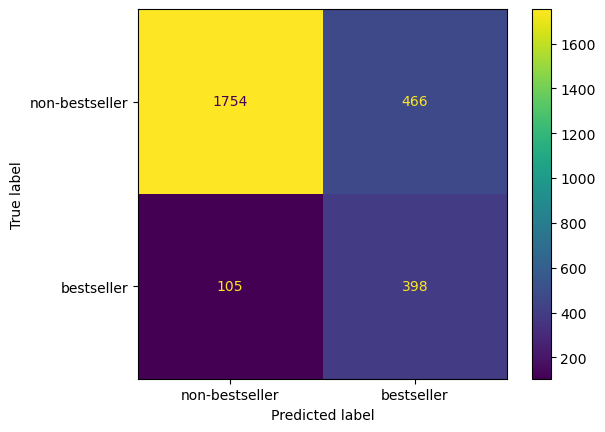

In [5]:
# Call evaluate_model(pipeline, X_test, y_test, 'Logistic Regression')
# Print classification report and confusion matrix

result_lr = evaluate_model(pipeline, X_test, y_test, 'Logistic Regression')

                 model  f1_macro  precision    recall   roc_auc
0  Logistic Regression  0.721156   0.460648  0.791252  0.859244
1             Always-0  0.449120   0.000000  0.000000       NaN
2             Always-1  0.155921   0.184723  1.000000       NaN


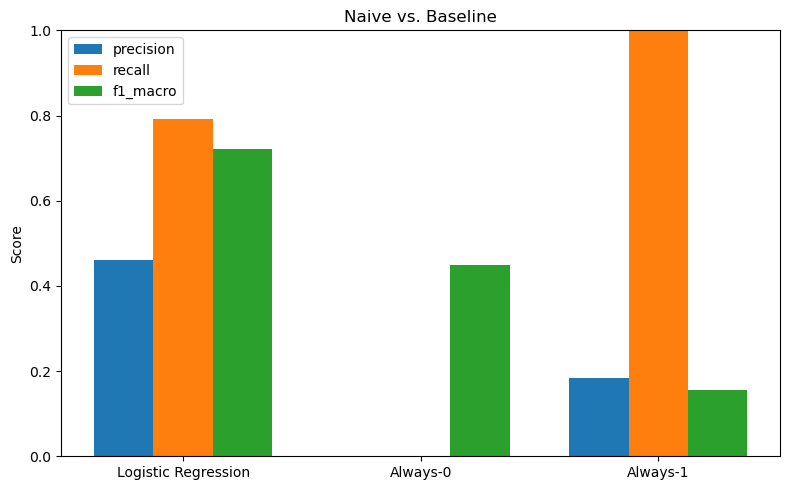

In [6]:
naive_results = [
    {
        'model': 'Always-0',
        'f1_macro': f1_score(y_test, np.zeros_like(y_test), average='macro', zero_division=0),
        'precision': precision_score(y_test, np.zeros_like(y_test), zero_division=0),
        'recall': recall_score(y_test, np.zeros_like(y_test), zero_division=0),
        'roc_auc': None,
    },
    {
        'model': 'Always-1',
        'f1_macro': f1_score(y_test, np.ones_like(y_test), average='macro', zero_division=0),
        'precision': precision_score(y_test, np.ones_like(y_test), zero_division=0),
        'recall': recall_score(y_test, np.ones_like(y_test), zero_division=0),
        'roc_auc': None,
    },
]

comparison = compare_models(naive_results + [result_lr])
print(comparison)

metrics = ['precision', 'recall', 'f1_macro']
x = np.arange(len(comparison))
width = 0.25

fig, ax = plt.subplots(figsize=(8, 5))
for i, m in enumerate(metrics):
    ax.bar(x + i * width, comparison[m], width, label=m)
ax.set_xticks(x + width)
ax.set_xticklabels(comparison['model'])
ax.set_ylabel('Score')
ax.set_ylim(0, 1)
ax.set_title('Naive vs. Baseline')
ax.legend()
plt.tight_layout()
plt.savefig(RESULTS_DIR / '03_naive_vs_baseline_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

## 5. Feature coefficients

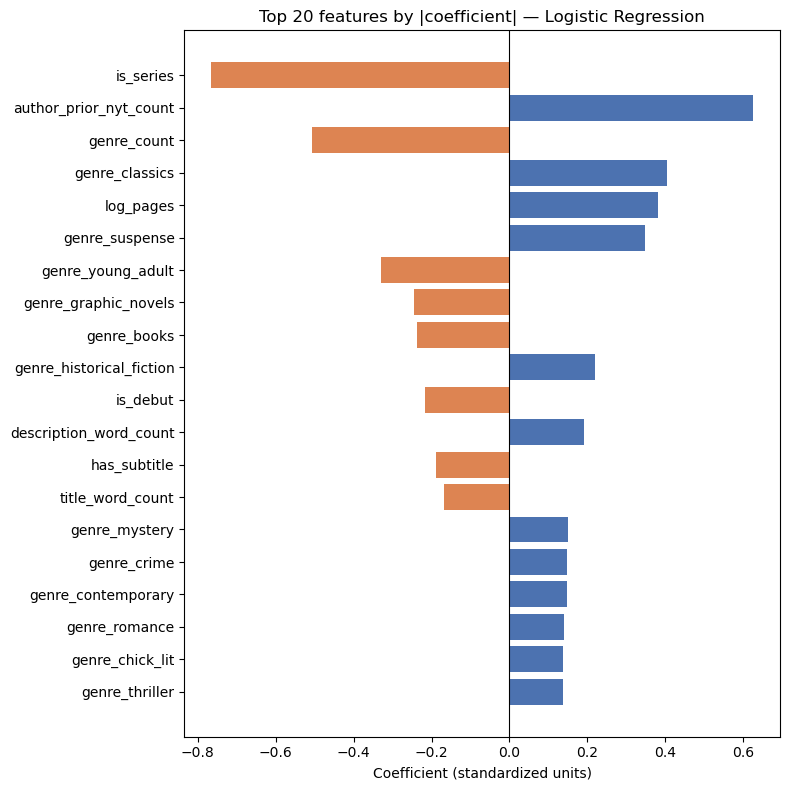

                 feature  coef_scaled
               is_series    -0.765149
  author_prior_nyt_count     0.625224
             genre_count    -0.507862
          genre_classics     0.405306
               log_pages     0.382502
          genre_suspense     0.349333
       genre_young_adult    -0.329302
    genre_graphic_novels    -0.243731
             genre_books    -0.236456
genre_historical_fiction     0.219897
                is_debut    -0.217920
  description_word_count     0.192109
            has_subtitle    -0.188560
        title_word_count    -0.168754
           genre_mystery     0.150789
             genre_crime     0.148744
      genre_contemporary     0.147015
           genre_romance     0.139214
         genre_chick_lit     0.138620
          genre_thriller     0.138184


In [7]:
# Extract coefficients from pipeline['clf'] after inverse-scaling
# Plot top-20 features by absolute coefficient magnitude
# Expected: author_prior_nyt_count and genre features should rank highly

clf = pipeline.named_steps['clf']
scaler = pipeline.named_steps['scaler']

coef_df = pd.DataFrame({
    'feature': X_train.columns,
    'coef_scaled': clf.coef_[0],
})
coef_df['abs_coef'] = coef_df['coef_scaled'].abs()
coef_df = coef_df.sort_values('abs_coef', ascending=False)

top20 = coef_df.head(20)

fig, ax = plt.subplots(figsize=(8, 8))
colors = ['#4C72B0' if c > 0 else '#DD8452' for c in top20['coef_scaled'][::-1]]
ax.barh(top20['feature'][::-1], top20['coef_scaled'][::-1], color=colors)
ax.axvline(0, color='black', linewidth=0.8)
ax.set_xlabel('Coefficient (standardized units)')
ax.set_title('Top 20 features by |coefficient| — Logistic Regression')
plt.tight_layout()
plt.savefig(RESULTS_DIR / '03_baseline_coefficients.png', dpi=150, bbox_inches='tight') 
plt.show()

print(top20[['feature', 'coef_scaled']].to_string(index=False))


In [8]:
# Only valid for slopes (not intercepts) -- dividing by scaler.scale_ undoes
# the standardization for coefficient interpretation in original units.
top10 = coef_df.head(10).copy()
top10['coef_raw_units'] = top10['coef_scaled'] / scaler.scale_[
    [list(X_train.columns).index(f) for f in top10['feature']]
]
print(top10[['feature', 'coef_scaled', 'coef_raw_units']].to_string(index=False))

                 feature  coef_scaled  coef_raw_units
               is_series    -0.765149       -1.530741
  author_prior_nyt_count     0.625224        0.282362
             genre_count    -0.507862       -0.279365
          genre_classics     0.405306        0.934594
               log_pages     0.382502        0.544971
          genre_suspense     0.349333        0.922038
       genre_young_adult    -0.329302       -0.737195
    genre_graphic_novels    -0.243731       -1.007973
             genre_books    -0.236456       -0.900161
genre_historical_fiction     0.219897        0.538490


### Feature coefficients — key findings

- Confirms expectations: `author_prior_nyt_count` (+0.57) rank highly, as anticipated.
- **`is_series` (-0.77) remains the single strongest feature
- `genre_count` (-0.51) is the #3 feature** — more genre tags on a book associates
  with a *lower* chance of bestseller status. Plausible mechanism: heavily-multi-tagged books skew
  toward niche/crossover fiction rather than mainstream commercial hits.
- `genre_graphic_novels` (-0.24) and `is_debut` (-0.22`). Graphic novels/comics are a distinct market segment
  rarely competing on Hardcover Fiction; debut authors (no prior book in this data) underperform
  established ones, a sensible and expected pattern.
- `genre_books` (-0.24) is a generic Goodreads shelf tag, not a real genre — treat with more
  skepticism than the other genre coefficients.